In [19]:
from course_utils.paths import get_project_root, get_data_dir
import pandas as pd
print("프로젝트 루트 :", get_project_root())
print("데이터 폴더 :", get_data_dir())

RAW_DIR = get_project_root() / "data" / "raw"
PROCESSED_DIR = get_project_root() / "data" / "processed"
REPORT_DIR = get_project_root() / "reports"
PROJECT_ROOT = get_project_root()


프로젝트 루트 : C:\dev\kant-axagent-study\llm-data-analysis-course
데이터 폴더 : C:\dev\kant-axagent-study\llm-data-analysis-course\data


In [20]:
import pandas as pd
import numpy as np

customers = pd.read_csv(get_data_dir()/"raw"/"customers.csv")
orders = pd.read_csv(get_data_dir()/"raw"/"orders.csv")
order_items = pd.read_csv(get_data_dir()/"raw"/"order_items.csv")
products = pd.read_csv(get_data_dir()/"raw"/"products.csv")

print(customers.head())
print(orders.head())
print(order_items.head())
print(products.head())

   customer_id name gender  age city signup_date
0            1  김수민      F   19   광주  2024-06-19
1            2  김정호      F   32   대구  2025-11-02
2            3  이경수      F   61   성남  2024-06-12
3            4  조영호      F   55   울산  2026-04-13
4            5  이예원      F   19   부산  2024-09-13
   order_id  customer_id  order_date payment_method order_status
0         1          123  2026-05-07           card    completed
1         2           77  2025-07-23      naver_pay    cancelled
2         3          138  2025-11-19  bank_transfer    cancelled
3         4           57  2026-01-30      kakao_pay    cancelled
4         5          125  2025-12-21           card    cancelled
   order_item_id  order_id  product_id  quantity  unit_price
0              1         1         100         3      102000
1              2         1          87         5       25000
2              3         1           7         3      142000
3              4         1           9         3      193000
4          

In [21]:
# matplotlib 그래프에서 한글이 깨지지 않도록, 현재 컴퓨터에 설치된 한글 폰트 중 사용 가능한 것을 찾아 자동으로 설정하는 코드, 음수 기호 깨짐도 방지
from matplotlib import font_manager
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ["Malgun Gothic", "AppleGothic", "Apple SD Gothic Neo", "Noto Sans CJK KR", "NanumGothic"]

import matplotlib.pyplot as plt

korean_font = next(
    (name for name in font_candidates if name in installed_fonts), None
)

print("선택된 한글 폰트: ", korean_font)

if korean_font:
    plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False

선택된 한글 폰트:  Malgun Gothic


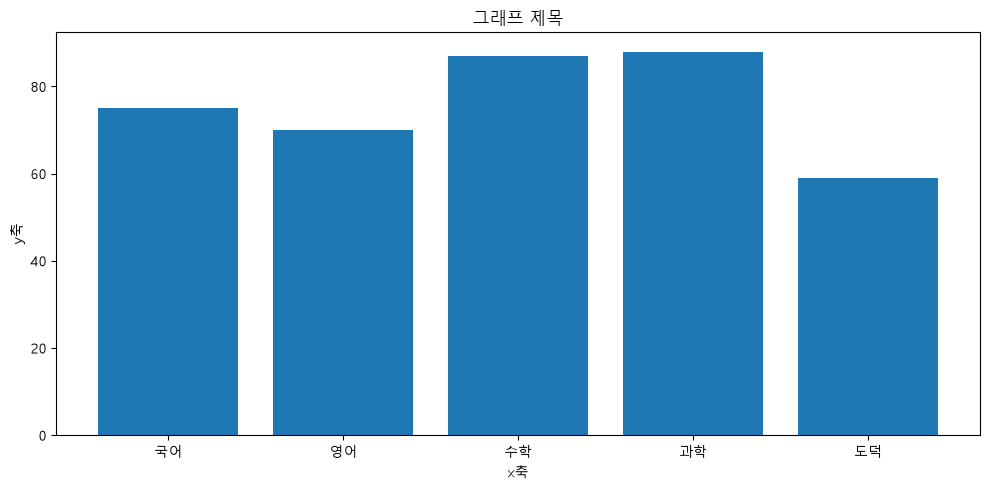

In [22]:
x_data = ["국어", "영어", "수학", "과학", "도덕"]
y_data = [75, 70, 87, 88, 59]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_data, y_data)
ax.set_title("그래프 제목")
ax.set_xlabel("x축")
ax.set_ylabel("y축")
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(
    "graph.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


In [23]:
orders.head()
orders["order_date"] = pd.to_datetime(orders["order_date"], errors = "raise")
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        300 non-null    int64         
 1   customer_id     300 non-null    int64         
 2   order_date      300 non-null    datetime64[us]
 3   payment_method  300 non-null    str           
 4   order_status    300 non-null    str           
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 17.0 KB


In [24]:
products_cleaned = pd.read_csv(PROCESSED_DIR/"products_clean.csv")
customers_cleaned = pd.read_csv(PROCESSED_DIR/"customers_clean.csv")
orders_cleaned = pd.read_csv(PROCESSED_DIR/"orders_clean.csv")
order_items_cleaned = pd.read_csv(PROCESSED_DIR/"order_items_clean.csv")
df_visualization = pd.read_csv(PROCESSED_DIR/"visualization.csv")

In [25]:
df_visualization.head()

,order_item_id,order_id,customer_id,product_id,order_date,order_month,order_dayofweek,payment_method,order_status,gender,...,product_name,category,price,quantity,unit_price,line_total,order_match,product_match,customer_match,merge_valid
0,1,1,144.0,39,2026-07-12,2026-07,Sunday,naver_pay,completed,F,...,뷰티 상품 039,뷰티,172000.0,2.0,172000.0,344000.0,True,True,True,True
1,2,2,149.0,26,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,뷰티 상품 026,뷰티,79000.0,4.0,79000.0,316000.0,True,True,True,True
2,3,2,149.0,46,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,생활용품 상품 046,생활용품,87000.0,3.0,87000.0,261000.0,True,True,True,True
3,4,2,149.0,80,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,패션 상품 080,패션,187000.0,1.0,187000.0,187000.0,True,True,True,True
4,5,2,149.0,91,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,전자기기 상품 091,전자기기,125000.0,5.0,125000.0,625000.0,True,True,True,True


In [26]:
df_visualization.info()

<class 'pandas.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    752 non-null    int64  
 1   order_id         752 non-null    int64  
 2   customer_id      750 non-null    float64
 3   product_id       752 non-null    int64  
 4   order_date       741 non-null    str    
 5   order_month      741 non-null    str    
 6   order_dayofweek  741 non-null    str    
 7   payment_method   750 non-null    str    
 8   order_status     750 non-null    str    
 9   gender           746 non-null    str    
 10  age              746 non-null    float64
 11  city             746 non-null    str    
 12  signup_date      734 non-null    str    
 13  product_name     726 non-null    str    
 14  category         726 non-null    str    
 15  price            726 non-null    float64
 16  quantity         752 non-null    float64
 17  unit_price       752 non-nu

In [27]:
df_visualization = df_visualization.dropna()
df_visualization.isna().sum().sum()

np.int64(0)

In [28]:
df_visualization.info()

<class 'pandas.DataFrame'>
Index: 700 entries, 0 to 751
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    700 non-null    int64  
 1   order_id         700 non-null    int64  
 2   customer_id      700 non-null    float64
 3   product_id       700 non-null    int64  
 4   order_date       700 non-null    str    
 5   order_month      700 non-null    str    
 6   order_dayofweek  700 non-null    str    
 7   payment_method   700 non-null    str    
 8   order_status     700 non-null    str    
 9   gender           700 non-null    str    
 10  age              700 non-null    float64
 11  city             700 non-null    str    
 12  signup_date      700 non-null    str    
 13  product_name     700 non-null    str    
 14  category         700 non-null    str    
 15  price            700 non-null    float64
 16  quantity         700 non-null    float64
 17  unit_price       700 non-null   

In [29]:
category_sales = df_visualization.groupby("category", dropna=False, as_index=False).agg(
    total_amount = ("line_total", sum),
    total_quantity = ("quantity", sum),
).sort_values("total_amount", ascending = False)

category_sales

,category,total_amount,total_quantity
9,패션,63322000.0,532.0
6,식품,45972000.0,384.0
8,전자기기,34218000.0,280.0
0,도서,27876000.0,272.0
2,뷰티,26467000.0,268.0
5,스포츠,20468000.0,253.0
4,생활용품,13835000.0,204.0
3,생활 용품,3224000.0,26.0
1,뷰 티,1026000.0,19.0
7,전자 기기,252000.0,12.0


In [30]:
df_visualization["category"] = (
    df_visualization["category"]
    .str.replace(" ", "", regex=False)
)

(0.0, 66488100.0)

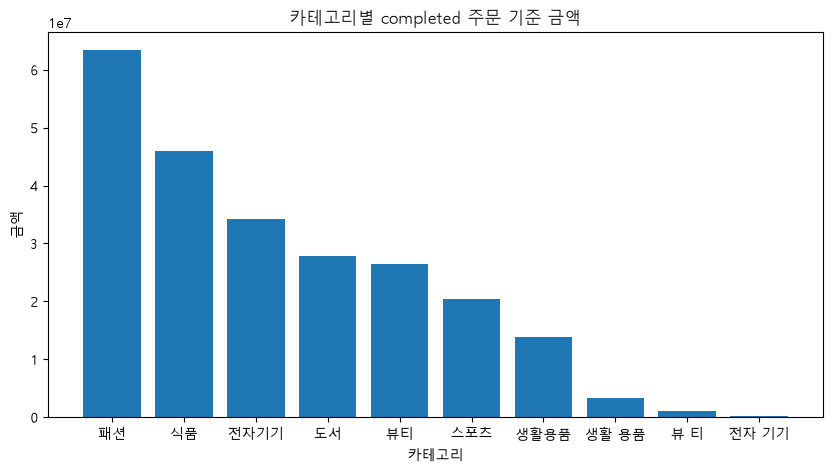

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    category_sales["category"],
    category_sales["total_amount"],
)
ax.set_title("카테고리별 completed 주문 기준 금액")
ax.set_xlabel("카테고리")
ax.set_ylabel("금액")
ax.set_ylim(bottom=0)

In [32]:
monthly_sales = df_visualization.groupby(df_visualization["order_month"],as_index=False).agg(
    total_amount = ("line_total", sum),
    order_count = ("order_id","nunique")
).sort_index()

Text(0, 0.5, '금액')

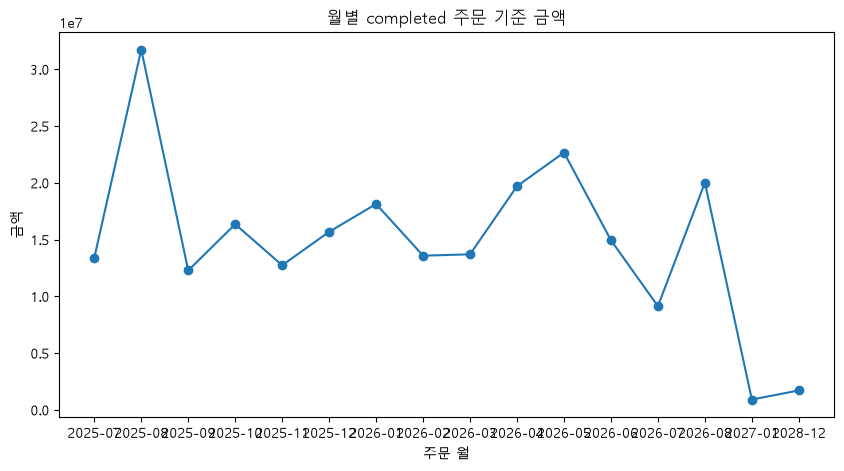

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    monthly_sales["order_month"],
    monthly_sales["total_amount"],
    marker="o"
)
ax.set_title("월별 completed 주문 기준 금액")
ax.set_xlabel("주문 월")
ax.set_ylabel("금액")


Text(0, 0.5, '상품 수')

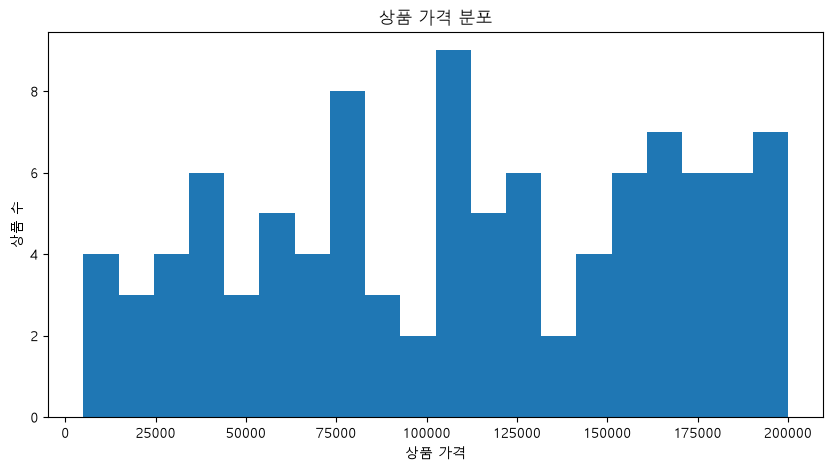

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    products["price"],
    bins=20,
)
ax.set_title("상품 가격 분포")
ax.set_xlabel("상품 가격")
ax.set_ylabel("상품 수")


In [35]:
df_visualization.info()

<class 'pandas.DataFrame'>
Index: 700 entries, 0 to 751
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    700 non-null    int64  
 1   order_id         700 non-null    int64  
 2   customer_id      700 non-null    float64
 3   product_id       700 non-null    int64  
 4   order_date       700 non-null    str    
 5   order_month      700 non-null    str    
 6   order_dayofweek  700 non-null    str    
 7   payment_method   700 non-null    str    
 8   order_status     700 non-null    str    
 9   gender           700 non-null    str    
 10  age              700 non-null    float64
 11  city             700 non-null    str    
 12  signup_date      700 non-null    str    
 13  product_name     700 non-null    str    
 14  category         700 non-null    str    
 15  price            700 non-null    float64
 16  quantity         700 non-null    float64
 17  unit_price       700 non-null   

In [36]:
product_sales = (
    df_visualization
    .groupby("product_id", as_index=False)
    .agg(
        unit_price=("unit_price", "mean"),
        completed_quantity=("quantity", "sum"),
    )
)

product_sales

,product_id,unit_price,completed_quantity
0,1,61000.0,20.0
1,2,154000.0,19.0
2,3,48000.0,7.0
3,4,33000.0,23.0
4,5,73000.0,24.0
...,...,...,...
91,96,96000.0,75.0
92,97,187000.0,31.0
93,98,32000.0,25.0
94,99,187000.0,18.0


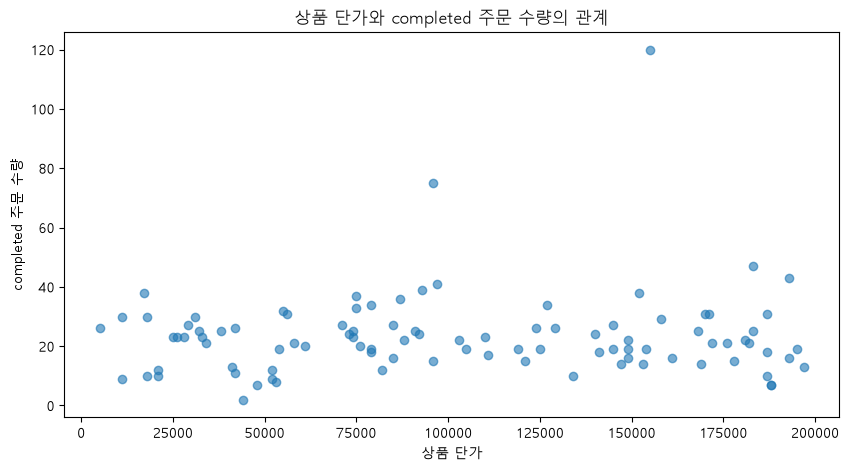

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    product_sales["unit_price"],
    product_sales["completed_quantity"],
    alpha=0.6,
)

ax.set_xlabel("상품 단가")
ax.set_ylabel("completed 주문 수량")
ax.set_title("상품 단가와 completed 주문 수량의 관계")

plt.show()

In [38]:
customer_sales = df_visualization.groupby("customer_id", dropna=False, as_index=False).agg(
    total_amount = ("line_total", sum),
    order_count = ("order_id", "nunique")
).sort_values("total_amount", ascending=False)
customer_sales

,customer_id,total_amount,order_count
15,18.0,16666000.0,2
2,3.0,8909000.0,7
17,20.0,6200000.0,6
45,52.0,5388000.0,5
11,14.0,5122000.0,4
...,...,...,...
105,131.0,176000.0,1
58,72.0,160000.0,1
70,86.0,128000.0,1
103,129.0,88000.0,1


In [39]:
top_customers = customer_sales.head(10).reset_index(drop=True)
top_customers

,customer_id,total_amount,order_count
0,18.0,16666000.0,2
1,3.0,8909000.0,7
2,20.0,6200000.0,6
3,52.0,5388000.0,5
4,14.0,5122000.0,4
5,55.0,4850000.0,6
6,90.0,4847000.0,5
7,22.0,4667000.0,4
8,15.0,4281000.0,5
9,115.0,3988000.0,4


<BarContainer object of 10 artists>

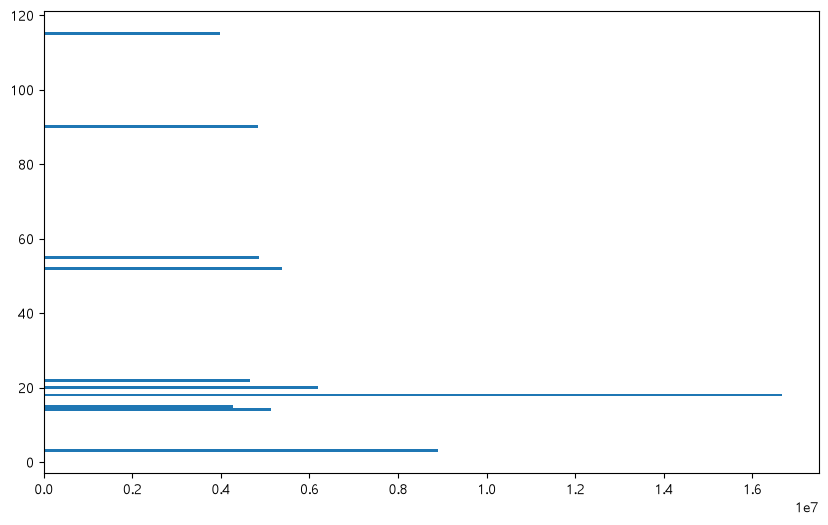

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(

    top_customers["customer_id"],

    top_customers["total_amount"],

)
